# Emilio Leon
## Web Scraping

In [32]:
import requests
import re
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import nltk
import spacy
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
tokenizer = nltk.WordPunctTokenizer()
nltk.download("stopwords")

def normalizar(texto):
    texto = texto.lower()
    texto = re.sub("[^a-zA-Zúíóáéñ\s]", "", texto, re.IGNORECASE)
    tokens = tokenizer.tokenize(texto)
    stop_words = nltk.corpus.stopwords.words("spanish")
    filtered_tokens = [token for token in tokens if token not in stop_words]
    corpus_normalizados = " ".join(filtered_tokens)
    return corpus_normalizados

normalizar_vc = np.vectorize(normalizar)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ealeo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
!python -m spacy download es_core_news_sm
nlp = spacy.load("es_core_news_sm")
def lematizar(texto):
    doc = nlp(str((texto)))
    lematizadas = [token.lemma_ for token in doc]
    corpus_lem = " ".join(lematizadas)
    return corpus_lem

lematizar_vc = np.vectorize(lematizar)

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.9 MB 14.1 MB/s eta 0:00:01
     --------------------- ------------------ 7.1/12.9 MB 21.5 MB/s eta 0:00:01
     --------------------------------------  12.8/12.9 MB 25.8 MB/s eta 0:00:01
     --------------------------------------- 12.9/12.9 MB 23.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
def enraizar(texto):
    stemmer = SnowballStemmer("spanish")
    palabras_con_raiz = []
    for palabra in texto:
        palabras_con_raiz.append(stemmer.stem(palabra))
    corpus_raiz = "".join(palabras_con_raiz)

    return corpus_raiz

enraizar_vc = np.vectorize(enraizar)

In [2]:
url = "https://www.eluniversal.com.mx/"
page_html = requests.get(url)

In [3]:
page_html.status_code

200

In [4]:
pip install html5lib


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
sopa = BeautifulSoup(page_html.text, "html5lib")

In [6]:
print("Título de la página web:\n\n", sopa.title)

Título de la página web:

 <title>El Universal | El periódico de México líder en noticias y clasificados</title>


In [7]:
for elemento in sopa.findAll("h2"):
    print(elemento.get_text())

Servicios
Principales
Baja 33% gasto militar en México con Sheinbaum 
Sheinbaum anuncia "acuerdo histórico" con la industria siderúrgica; va por fortalecer producción nacional de acero
Ariadna Montiel va por la dirigencia de Morena; deja la Secretaría del Bienestar y Leticia Ramírez la reemplaza
Detienen a cuatro por multihomicidio en Azcapotzalco; operativo conjunto logra captura
Farías lavaba dinero mediante operaciones con seguros de vida: FGR
Opinión
Brugada responde al Verde
Mario Bros pierde su estrella en taquilla, pero nadie lo alcanza
Encopetado
Un extraño enemigo
Colección Gelman, una “marca registrada”
Testamento Gelman ¿proceso legal por violarlo?
Usos y costumbres someten a niñas a uniones forzadas 
Portada
Elecciones y Encuestas
Destape de Jesús Sesma “está muy verde”, indica Brugada
Tatiana Clouthier busca la gubernatura de Nuevo León; "soy la más preparada", afirma
El 60% de mexiquenses aprueba gestión de Delfina
Morena prepara relevo de dirigencia nacional; ¿cómo se de

In [8]:
for elemento in sopa.findAll("h4"):
    print(elemento.get_text())

.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}Sube el precio del PT y Verde en la 4T 
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}Al narco que AMLO dejó crecer seis años, lo detuvieron en 19 meses  
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}Autopsia de un montaje
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}Entre Trump y los duros
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}La colaboración México-EU bajo presión
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}El giro de Sheinbaum
Quitan subsidio a gasolina Premium; bajan estímulos a Magna y diésel por caída del petróleo
Usos y costumbres someten a niñas a uniones forzadas 
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}Elecciones simultáneas en 2027: la ruta hacia la tormenta perfecta  
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}Las infancias que estamos perdiendo
.st0{fill:#FFFFFF;}.st1{fill:#F7B318;}.st2{fill:#E5A324;}Irresponsabilidad si

In [10]:
for elemento in sopa.findAll("h4"):
    if elemento.has_attr("data-cta"):
        print(elemento["data-cta"])

Sube el precio del PT y Verde en la 4T 
Al narco que AMLO dejó crecer seis años, lo detuvieron en 19 meses  
Autopsia de un montaje
Entre Trump y los duros
La colaboración México-EU bajo presión
El giro de Sheinbaum
Elecciones simultáneas en 2027: la ruta hacia la tormenta perfecta  
Las infancias que estamos perdiendo
Irresponsabilidad sin precedentes
No es proteger a los seres sintientes, es contenernos
¿Enjuiciará Trump a políticos mexicanos?
La comunidad del crimen real
El derecho a la privacidad después de un divorcio
La productividad legislativa  
El reino del revés: condenar a quien da resultados
El Día de las Infancias: Un compromiso con los derechos de niñas y niños
El mito de Sísifo y sus likes
La desconexión del centro con los estados 


In [22]:
corpus = [elemento["data-cta"] for elemento in sopa.findAll("h4")
           if elemento.has_attr("data-cta")]

In [23]:
corpus

['Sube el precio del PT y Verde en la 4T ',
 'Al narco que AMLO dejó crecer seis años, lo detuvieron en 19 meses  ',
 'Autopsia de un montaje',
 'Entre Trump y los duros',
 'La colaboración México-EU bajo presión',
 'El giro de Sheinbaum',
 'Elecciones simultáneas en 2027: la ruta hacia la tormenta perfecta  ',
 'Las infancias que estamos perdiendo',
 'Irresponsabilidad sin precedentes',
 'No es proteger a los seres sintientes, es contenernos',
 '¿Enjuiciará Trump a políticos mexicanos?',
 'La comunidad del crimen real',
 'El derecho a la privacidad después de un divorcio',
 'La productividad legislativa  ',
 'El reino del revés: condenar a quien da resultados',
 'El Día de las Infancias: Un compromiso con los derechos de niñas y niños',
 'El mito de Sísifo y sus likes',
 'La desconexión del centro con los estados ']

In [29]:
corpus = normalizar_vc(corpus)

C:\Users\ealeo\AppData\Local\Temp\ipykernel_6976\1327117606.py:6: DeprecationWarning: 'count' is passed as positional argument
  texto = re.sub("[^a-zA-Zúíóáéñ\s]", "", texto, re.IGNORECASE)


In [30]:
corpus = lematizar_vc(corpus)

In [31]:
corpus

array(['subir precio pt verde t',
       'narco amlo dejar crecer seis año detener 9 mes',
       'autopsia montaje', 'trump duro',
       'colaboración méxicoeu bajo presión', 'giro sheinbaum',
       'elección simultáneo 27 : rutar hacia tormenta perfecto',
       'infancia perder', 'irresponsabilidad precedente',
       'proteger ser sintient contenerno',
       'enjuiciar trump político mexicano', 'comunidad crimen real',
       'derecho privacidad después divorcio', 'productividad legislativo',
       'reino revés condenar dar resultado',
       'día infancia compromiso derechos niñas niño', 'mito sísifo likes',
       'desconexión centro'], dtype='<U54')

In [33]:
count_vectorizer = CountVectorizer(min_df=0.0 , max_df=1.0)
matriz_conteo = count_vectorizer.fit_transform(corpus)
matriz_conteo = matriz_conteo.toarray()

In [34]:
matriz_conteo

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [35]:
vocabulario = count_vectorizer.get_feature_names_out()

In [36]:
df = pd.DataFrame(matriz_conteo, columns=vocabulario)

In [37]:
df

,27,amlo,autopsia,año,bajo,centro,colaboración,compromiso,comunidad,condenar,...,seis,ser,sheinbaum,simultáneo,sintient,subir,sísifo,tormenta,trump,verde
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,0,1,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0


In [38]:
df_tras = df.T
df_tras

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
27,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
amlo,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
autopsia,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
año,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bajo,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
subir,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sísifo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
tormenta,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
trump,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [62]:
from nltk.probability import FreqDist

In [63]:
palabras = []
for documento in corpus:
    for palabra in documento.split():
        palabras.append(palabra)

In [64]:
freq = nltk.FreqDist(palabras)

In [65]:
frecuencia_palabras = pd.DataFrame(freq.most_common(10))

In [66]:
frecuencia_palabras.columns = ["palabra", "frecuencia"]

In [67]:
frecuencia_palabras

,palabra,frecuencia
0,trump,2
1,infancia,2
2,subir,1
3,precio,1
4,pt,1
5,verde,1
6,t,1
7,narco,1
8,amlo,1
9,dejar,1


In [68]:
import matplotlib.pyplot as plt

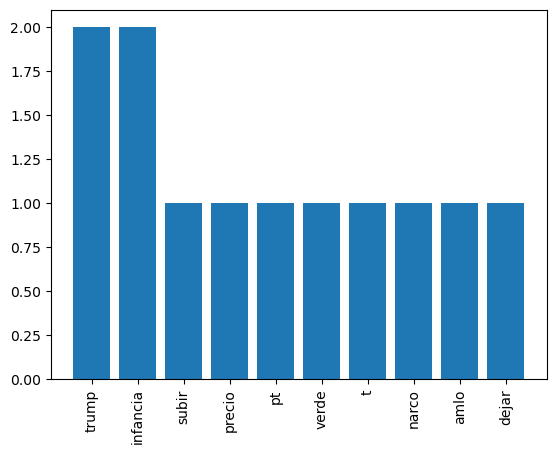

In [69]:
plt.bar(frecuencia_palabras["palabra"], frecuencia_palabras["frecuencia"])
plt.xticks(rotation=90)
plt.show()

In [71]:
from wordcloud import WordCloud

In [78]:
nube_palabras = WordCloud().generate(" ".join(frecuencia_palabras["palabra"]))

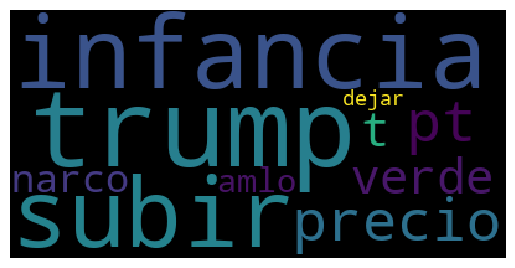

In [79]:
plt.imshow(nube_palabras, interpolation="nearest")
plt.axis("off")
plt.show()

In [80]:
!python -m spacy download es_core_news_sm

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.9 MB 11.1 MB/s eta 0:00:02
     --------- ------------------------------ 3.1/12.9 MB 11.7 MB/s eta 0:00:01
     ------------------- -------------------- 6.3/12.9 MB 13.4 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.9 MB 14.2 MB/s eta 0:00:01
     ------------------------------------- - 12.3/12.9 MB 13.6 MB/s eta 0:00:01
     --------------------------------------- 12.9/12.9 MB 13.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
import spacy
nlp = spacy.load("es_core_news_sm")

In [85]:
documento = nlp(str((corpus)))

In [87]:
for palabra in documento:
    if palabra.pos_ in ["NOUN", "PROPN"]:
        print(palabra.text, palabra.pos_)

[ NOUN
precio NOUN
narco PROPN
amlo NOUN
año NOUN
mes NOUN
autopsia PROPN
montaje NOUN
colaboración NOUN
méxicoeu PROPN
presión NOUN
giro NOUN
sheinbaum PROPN
elección NOUN
tormenta NOUN
infancia NOUN
irresponsabilidad NOUN
sintient PROPN
contenerno NOUN
trump NOUN
comunidad NOUN
crimen NOUN
privacidad NOUN
divorcio NOUN
productividad NOUN
reino PROPN
revés PROPN
resultado NOUN
día NOUN
infancia NOUN
compromiso NOUN
derechos NOUN
niñas PROPN
niño PROPN
mito NOUN
likes PROPN
desconexión NOUN
centro NOUN


In [88]:
for palabra in documento:
    if palabra.pos_ == "ADJ":
        print(palabra.text, palabra.pos_)

verde ADJ
duro ADJ
simultáneo ADJ
perfecto ADJ
precedente ADJ
político ADJ
mexicano ADJ
real ADJ
derecho ADJ
legislativo ADJ
sísifo ADJ


In [89]:
for palabra in documento:
    if palabra.pos_ == "VERB":
        print(palabra.text, palabra.pos_)

subir VERB
pt VERB
dejar VERB
crecer VERB
detener VERB
trump VERB
rutar VERB
perder VERB
proteger VERB
enjuiciar VERB
condenar VERB
dar VERB
] VERB
